# 04 — Ward Agent RL Training

This notebook trains Ward-level Reinforcement Learning policies (PPO / DQN) using Stable-Baselines3. 
It tests agents across multiple diverse scenarios (normal, peak, chaos) and different wards, collecting Temporal GNN dataset data simultaneously.

The environment runs headless (no GUI) for maximum training speed.

In [1]:
import sys
from pathlib import Path
from IPython.display import Image, display

# Ensure project root is in path
PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.rl.train import train_global_agent
from configs.scenarios import list_scenarios

C:\Users\satya\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Configuration

We select 16 representative wards across different areas, and 6 diverse stress-testing scenarios. The models will train across all of these randomly.

In [ ]:
# Wards covering HSR, BTM Layout, and other areas
TARGET_WARDS = [
    "ward_070", "ward_071", "ward_072", 
    "ward_017", "ward_018",
    #  "ward_019", "ward_020",
    # "ward_007", "ward_008", "ward_009", "ward_010", 
    # "ward_011", "ward_012", "ward_013", "ward_014", "ward_015"
]

# Use all newly consolidated stress scenarios
TARGET_SCENARIOS = list_scenarios()
print(f"Training on {len(TARGET_WARDS)} wards across {len(TARGET_SCENARIOS)} scenarios:")
print(TARGET_SCENARIOS)

Training on 16 wards across 6 scenarios:
['normal', 'peak_congestion', 'breakdown_cascade', 'ambulance_emergency', 'vip_convoy', 'chaos_mode']


## 2. Train PPO Agent

Proximal Policy Optimization is stable and handles continuous-like stochastic behavior well. We also instruct it to collect GNN training data (`collect_gnn_data=True`) to be used later.

In [ ]:
print("Starting PPO Training...")

ppo_results = train_global_agent(
    ward_ids=TARGET_WARDS,
    scenario_ids=TARGET_SCENARIOS,
    project_root=PROJECT_ROOT,
    algorithm="ppo",
    episodes=100,            # 300 episodes for demonstration
    gui=False,
    collect_gnn_data=True    # Capture features for Area models
)

print("\n✅ PPO Training Complete!")
print(f"Model saved to: {ppo_results['model_path']}")
print(f"GNN Dataset saved to: {ppo_results['gnn_data_path']}")

Starting PPO Training...


RL Agent Training: 100%|██████████| 200/200 [1:09:01<00:00, 20.71s/it, ep_reward=-270.1, avg_10_ep=-260.0]



✅ PPO Training Complete!
Model saved to: D:\Bunker\BaseCamp\Hierarchical-multi-agent-RL-for-Urban-Traffic\models\ppo\global_agent\model.pt
GNN Dataset saved to: D:\Bunker\BaseCamp\Hierarchical-multi-agent-RL-for-Urban-Traffic\models\gnn\global_temporal_data.pt


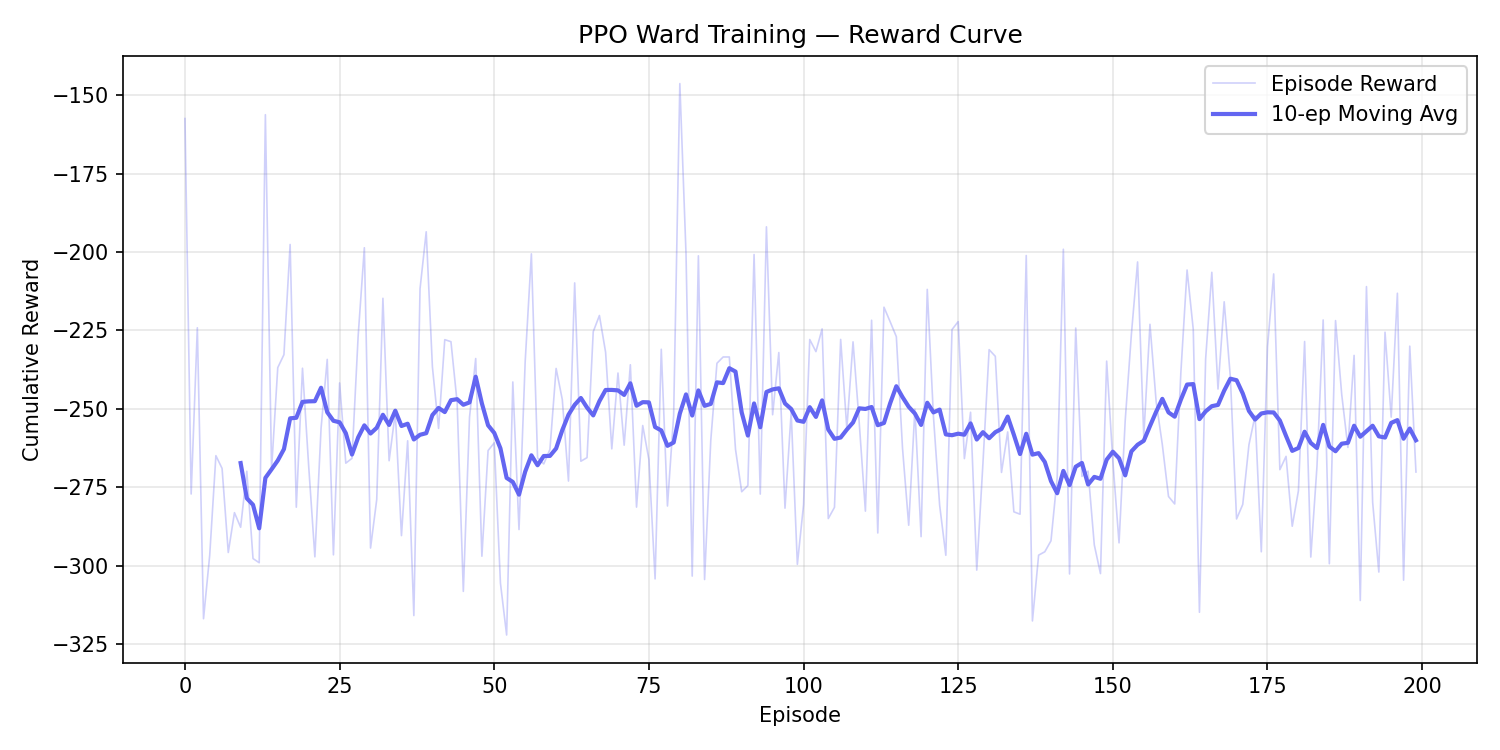

In [4]:
# Display PPO Reward Curve
display(Image(filename="../results/training/ward_ppo_reward_curve.png"))

## 3. Train DQN Agent

Deep Q-Networks provide a strong baseline for off-policy learning in discrete action spaces.

In [ ]:
print("Starting DQN Training...")

dqn_results = train_global_agent(
    ward_ids=TARGET_WARDS,
    scenario_ids=TARGET_SCENARIOS,
    project_root=PROJECT_ROOT,
    algorithm="dqn",
    episodes=100,
    gui=False,
    collect_gnn_data=False   # Already collected with PPO
)

print("\n✅ DQN Training Complete!")
print(f"Model saved to: {dqn_results['model_path']}")

Starting DQN Training...


RL Agent Training:  54%|█████▎    | 107/200 [1:07:35<1:31:26, 59.00s/it, ep_reward=-231.8, avg_10_ep=-251.0]

KeyboardInterrupt: 

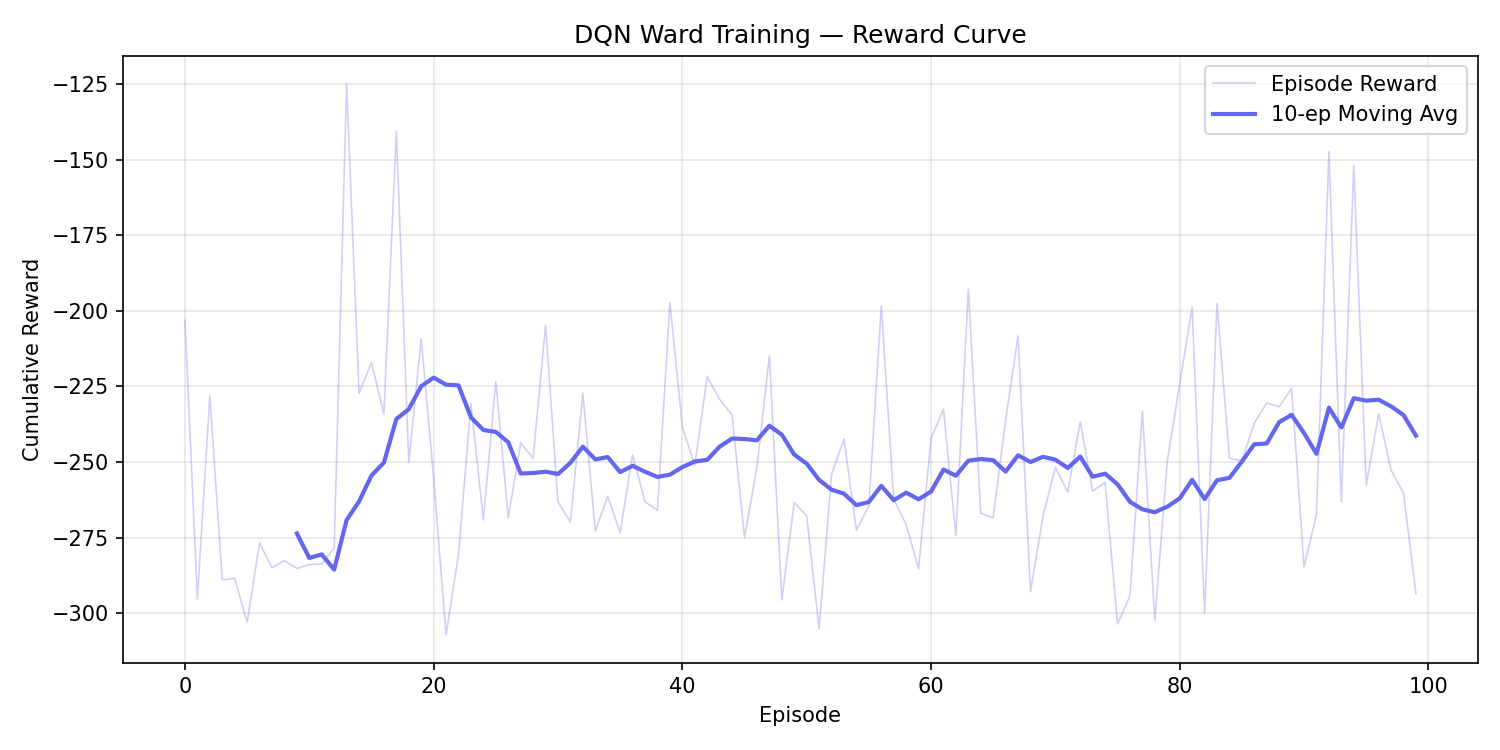

In [ ]:
# Display DQN Reward Curve
display(Image(filename="../results/training/ward_dqn_reward_curve.png"))

## 4. Inference Test

Load the trained `WardAgent` inference wrapper and verify policy outputs on dummy observation vectors.

In [7]:
import numpy as np
from src.controllers.ward_agent import WardAgent, OBSERVATION_DIM

# Create random observation (simulating 30-timesteps * 7 features = 210 dim)
dummy_obs = np.random.rand(OBSERVATION_DIM).astype(np.float32)

agent_ppo = WardAgent("test", Path(ppo_results["model_path"]))
action = agent_ppo.get_action(dummy_obs)
probs = agent_ppo.get_action_probs(dummy_obs)

print(f"Selected Action Index: {action}")
print(f"Action Probabilities: \n{np.round(probs, 3)}")

Selected Action Index: 7
Action Probabilities: 
[0.091 0.098 0.104 0.097 0.098 0.095 0.097 0.11  0.102 0.107]
